In [1]:
import pandas as pd
from pathlib import Path
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
import xgboost
from xgboost import XGBClassifier
from sklearn.base import clone
from sklearn.ensemble import (
    AdaBoostClassifier,
    BaggingClassifier,
    ExtraTreesClassifier,
    GradientBoostingClassifier,
    RandomForestClassifier,
    StackingClassifier,
    VotingClassifier
)
from sklearn.compose import ColumnTransformer
from sklearn.impute import SimpleImputer
from sklearn.inspection import PartialDependenceDisplay, permutation_importance
from sklearn.metrics import (
    accuracy_score,
    average_precision_score,
    balanced_accuracy_score,
    brier_score_loss,
    classification_report,
    confusion_matrix,
    log_loss,
    roc_auc_score,
    roc_curve
)
from sklearn.pipeline import Pipeline
from sklearn.preprocessing import StandardScaler, OneHotEncoder
from sklearn.calibration import CalibratedClassifierCV, CalibrationDisplay
from sklearn.tree import DecisionTreeClassifier
import warnings
warnings.filterwarnings('ignore')
from sklearn.model_selection import train_test_split, StratifiedKFold

In [2]:
# Get the Data
train = pd.read_csv("data/Train.csv")
test = pd.read_csv("data/Test.csv")

print("Train shape:", train.shape)
print("Test shape:", test.shape)

print(train.head())
print(test.head())

Train shape: (30557, 82)
Test shape: (16136, 77)
        Place_ID X Date        Date Place_ID  target  target_min  target_max  \
0  010Q650 X 2020-01-02  2020-01-02  010Q650    38.0        23.0        53.0   
1  010Q650 X 2020-01-03  2020-01-03  010Q650    39.0        25.0        63.0   
2  010Q650 X 2020-01-04  2020-01-04  010Q650    24.0         8.0        56.0   
3  010Q650 X 2020-01-05  2020-01-05  010Q650    49.0        10.0        55.0   
4  010Q650 X 2020-01-06  2020-01-06  010Q650    21.0         9.0        52.0   

   target_variance  target_count  precipitable_water_entire_atmosphere  \
0           769.50            92                             11.000000   
1          1319.85            91                             14.600000   
2          1181.96            96                             16.400000   
3          1113.67            96                              6.911948   
4          1164.82            95                             13.900001   

   relative_humidity_2m_a

In [3]:
# First Look at the Data
train_columns = set(train.columns)
test_columns = set(test.columns)

# target is the daily PM2.5 particulate matter concentration for each city.
target_columns = train_columns - test_columns
target_name = "target"

if target_name not in target_columns:
    raise ValueError(f"'{target_name}' was not found in train-only columns: {target_columns}")


print("Target column:", target_name)


Target column: target


In [4]:
numerical_variables = train.select_dtypes(
    include=["number"]
).columns.tolist()

categorical_variables = train.select_dtypes(
    include=["object", "category"]
).columns.tolist()

print("Numerical variables:")
print(numerical_variables)

print("\nCategorical variables:")
print(categorical_variables)

Numerical variables:
['target', 'target_min', 'target_max', 'target_variance', 'target_count', 'precipitable_water_entire_atmosphere', 'relative_humidity_2m_above_ground', 'specific_humidity_2m_above_ground', 'temperature_2m_above_ground', 'u_component_of_wind_10m_above_ground', 'v_component_of_wind_10m_above_ground', 'L3_NO2_NO2_column_number_density', 'L3_NO2_NO2_slant_column_number_density', 'L3_NO2_absorbing_aerosol_index', 'L3_NO2_cloud_fraction', 'L3_NO2_sensor_altitude', 'L3_NO2_sensor_azimuth_angle', 'L3_NO2_sensor_zenith_angle', 'L3_NO2_solar_azimuth_angle', 'L3_NO2_solar_zenith_angle', 'L3_NO2_stratospheric_NO2_column_number_density', 'L3_NO2_tropopause_pressure', 'L3_NO2_tropospheric_NO2_column_number_density', 'L3_O3_O3_column_number_density', 'L3_O3_O3_effective_temperature', 'L3_O3_cloud_fraction', 'L3_O3_sensor_azimuth_angle', 'L3_O3_sensor_zenith_angle', 'L3_O3_solar_azimuth_angle', 'L3_O3_solar_zenith_angle', 'L3_CO_CO_column_number_density', 'L3_CO_H2O_column_number_d

In [5]:
# Exclude the target, target-derived summaries, and identifier/date columns.
target_derived_columns = target_columns
columns_to_exclude = target_derived_columns | {"Place_ID X Date", "Date", "Place_ID"}
X_train = train.drop(columns=list(columns_to_exclude))
y_train = train[target_name]

print("Columns excluded from features:", columns_to_exclude)
print("X feature :", X_train.columns.tolist())

Columns excluded from features: {'target_max', 'target_count', 'target_min', 'target', 'Place_ID', 'target_variance', 'Place_ID X Date', 'Date'}
X feature : ['precipitable_water_entire_atmosphere', 'relative_humidity_2m_above_ground', 'specific_humidity_2m_above_ground', 'temperature_2m_above_ground', 'u_component_of_wind_10m_above_ground', 'v_component_of_wind_10m_above_ground', 'L3_NO2_NO2_column_number_density', 'L3_NO2_NO2_slant_column_number_density', 'L3_NO2_absorbing_aerosol_index', 'L3_NO2_cloud_fraction', 'L3_NO2_sensor_altitude', 'L3_NO2_sensor_azimuth_angle', 'L3_NO2_sensor_zenith_angle', 'L3_NO2_solar_azimuth_angle', 'L3_NO2_solar_zenith_angle', 'L3_NO2_stratospheric_NO2_column_number_density', 'L3_NO2_tropopause_pressure', 'L3_NO2_tropospheric_NO2_column_number_density', 'L3_O3_O3_column_number_density', 'L3_O3_O3_effective_temperature', 'L3_O3_cloud_fraction', 'L3_O3_sensor_azimuth_angle', 'L3_O3_sensor_zenith_angle', 'L3_O3_solar_azimuth_angle', 'L3_O3_solar_zenith_angle

In [6]:
len(X_train.columns)

74

In [7]:
X_train.columns.tolist()

['precipitable_water_entire_atmosphere',
 'relative_humidity_2m_above_ground',
 'specific_humidity_2m_above_ground',
 'temperature_2m_above_ground',
 'u_component_of_wind_10m_above_ground',
 'v_component_of_wind_10m_above_ground',
 'L3_NO2_NO2_column_number_density',
 'L3_NO2_NO2_slant_column_number_density',
 'L3_NO2_absorbing_aerosol_index',
 'L3_NO2_cloud_fraction',
 'L3_NO2_sensor_altitude',
 'L3_NO2_sensor_azimuth_angle',
 'L3_NO2_sensor_zenith_angle',
 'L3_NO2_solar_azimuth_angle',
 'L3_NO2_solar_zenith_angle',
 'L3_NO2_stratospheric_NO2_column_number_density',
 'L3_NO2_tropopause_pressure',
 'L3_NO2_tropospheric_NO2_column_number_density',
 'L3_O3_O3_column_number_density',
 'L3_O3_O3_effective_temperature',
 'L3_O3_cloud_fraction',
 'L3_O3_sensor_azimuth_angle',
 'L3_O3_sensor_zenith_angle',
 'L3_O3_solar_azimuth_angle',
 'L3_O3_solar_zenith_angle',
 'L3_CO_CO_column_number_density',
 'L3_CO_H2O_column_number_density',
 'L3_CO_cloud_height',
 'L3_CO_sensor_altitude',
 'L3_CO_se

In [8]:
y_train.name

'target'

In [ ]:
X_train.isnull().sum()



precipitable_water_entire_atmosphere        0
relative_humidity_2m_above_ground           0
specific_humidity_2m_above_ground           0
temperature_2m_above_ground                 0
u_component_of_wind_10m_above_ground        0
                                        ...  
L3_CH4_aerosol_optical_depth            24765
L3_CH4_sensor_azimuth_angle             24765
L3_CH4_sensor_zenith_angle              24765
L3_CH4_solar_azimuth_angle              24765
L3_CH4_solar_zenith_angle               24765
Length: 74, dtype: int64

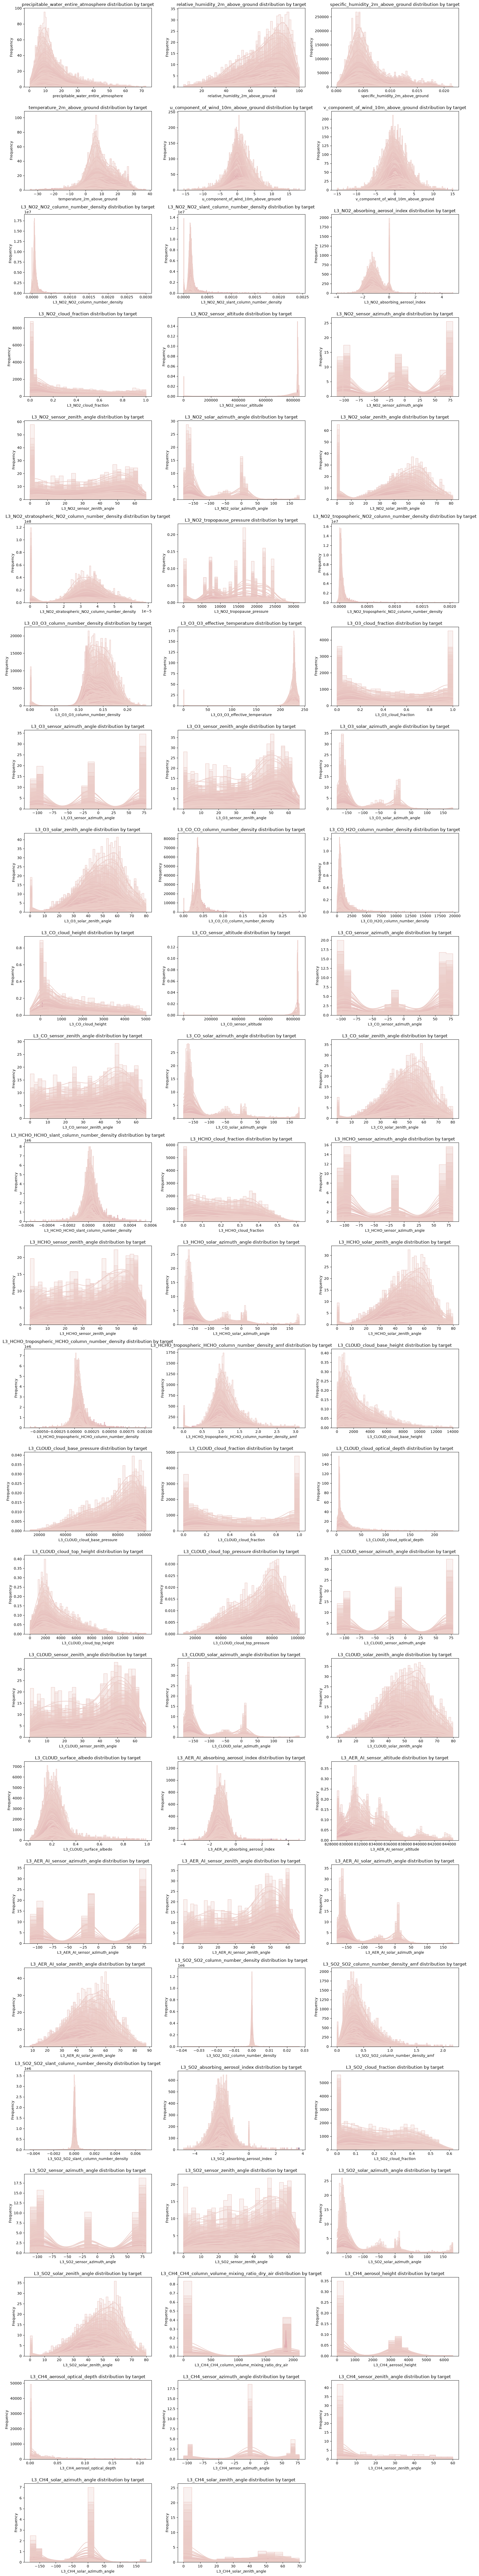

In [17]:
# Plot all numerical feature variables
numerical_features = X_train.select_dtypes(include=np.number).columns.tolist()
plot_data = X_train.copy()
plot_data["target"] = y_train

n_features = len(numerical_features)
n_columns = 3
n_rows = int(np.ceil(n_features / n_columns))

fig, axes = plt.subplots(
    n_rows,
    n_columns,
    figsize=(18, 4 * n_rows),
    squeeze=False
)
axes = axes.ravel()

for axis, column in zip(axes, numerical_features):
    sns.histplot(
        data=plot_data,
        x=column,
        hue="target",
        kde=True,
        element="step",
        stat="frequency",
        common_norm=False,
        ax=axis,
        legend=False
    )
    axis.set_title(f"{column} distribution by target")

for axis in axes[n_features:]:
    axis.remove()

plt.tight_layout()
plt.show()

In [10]:
sns.pairplot(
    X_train,
    corner=True,
    diag_kind="hist"
)
plt.show()

KeyboardInterrupt: 

In [11]:
missing_summary = pd.DataFrame({
    "missing_count": X_train.isna().sum(),
    "missing_percentage": X_train.isna().mean() * 100
})

missing_summary = missing_summary[
    missing_summary["missing_count"] > 0
].sort_values("missing_count", ascending=False)

missing_summary

,missing_count,missing_percentage
L3_CH4_solar_zenith_angle,24765,81.045260
L3_CH4_sensor_zenith_angle,24765,81.045260
L3_CH4_sensor_azimuth_angle,24765,81.045260
L3_CH4_aerosol_height,24765,81.045260
L3_CH4_CH4_column_volume_mixing_ratio_dry_air,24765,81.045260
...,...,...
L3_AER_AI_solar_azimuth_angle,197,0.644697
L3_AER_AI_sensor_altitude,197,0.644697
L3_AER_AI_absorbing_aerosol_index,197,0.644697
L3_AER_AI_sensor_zenith_angle,197,0.644697


In [12]:
# Descriptive statistics
display(X_train.describe().T.round(2))

,count,mean,std,min,25%,50%,75%,max
precipitable_water_entire_atmosphere,30557.0,15.30,10.69,0.42,7.67,12.20,19.90,72.60
relative_humidity_2m_above_ground,30557.0,70.55,18.81,5.13,58.60,74.10,85.45,100.00
specific_humidity_2m_above_ground,30557.0,0.01,0.00,0.00,0.00,0.00,0.01,0.02
temperature_2m_above_ground,30557.0,9.32,9.34,-34.65,3.12,8.48,16.20,37.44
u_component_of_wind_10m_above_ground,30557.0,0.42,2.71,-15.56,-1.10,0.22,1.77,17.96
...,...,...,...,...,...,...,...,...
L3_CH4_aerosol_optical_depth,5792.0,0.02,0.03,0.00,0.00,0.00,0.02,0.21
L3_CH4_sensor_azimuth_angle,5792.0,1.25,55.10,-105.37,0.00,0.00,62.25,77.36
L3_CH4_sensor_zenith_angle,5792.0,13.85,18.00,0.00,0.00,0.00,27.41,59.97
L3_CH4_solar_azimuth_angle,5792.0,-69.10,84.70,-179.95,-161.73,0.00,0.00,179.81


In [13]:
display(X_train.nunique().sort_values().rename('n_unique').to_frame())

,n_unique
L3_CH4_aerosol_height,2874
L3_CH4_solar_zenith_angle,2874
L3_CH4_solar_azimuth_angle,2874
L3_CH4_sensor_zenith_angle,2874
L3_CH4_sensor_azimuth_angle,2874
...,...
L3_AER_AI_sensor_altitude,30360
L3_AER_AI_sensor_azimuth_angle,30360
L3_AER_AI_sensor_zenith_angle,30360
L3_AER_AI_solar_zenith_angle,30360


<class 'pandas.DataFrame'>
RangeIndex: 30557 entries, 0 to 30556
Data columns (total 74 columns):
 #   Column                                               Non-Null Count  Dtype  
---  ------                                               --------------  -----  
 0   precipitable_water_entire_atmosphere                 30557 non-null  float64
 1   relative_humidity_2m_above_ground                    30557 non-null  float64
 2   specific_humidity_2m_above_ground                    30557 non-null  float64
 3   temperature_2m_above_ground                          30557 non-null  float64
 4   u_component_of_wind_10m_above_ground                 30557 non-null  float64
 5   v_component_of_wind_10m_above_ground                 30557 non-null  float64
 6   L3_NO2_NO2_column_number_density                     28368 non-null  float64
 7   L3_NO2_NO2_slant_column_number_density               28368 non-null  float64
 8   L3_NO2_absorbing_aerosol_index                       28368 non-null  float64


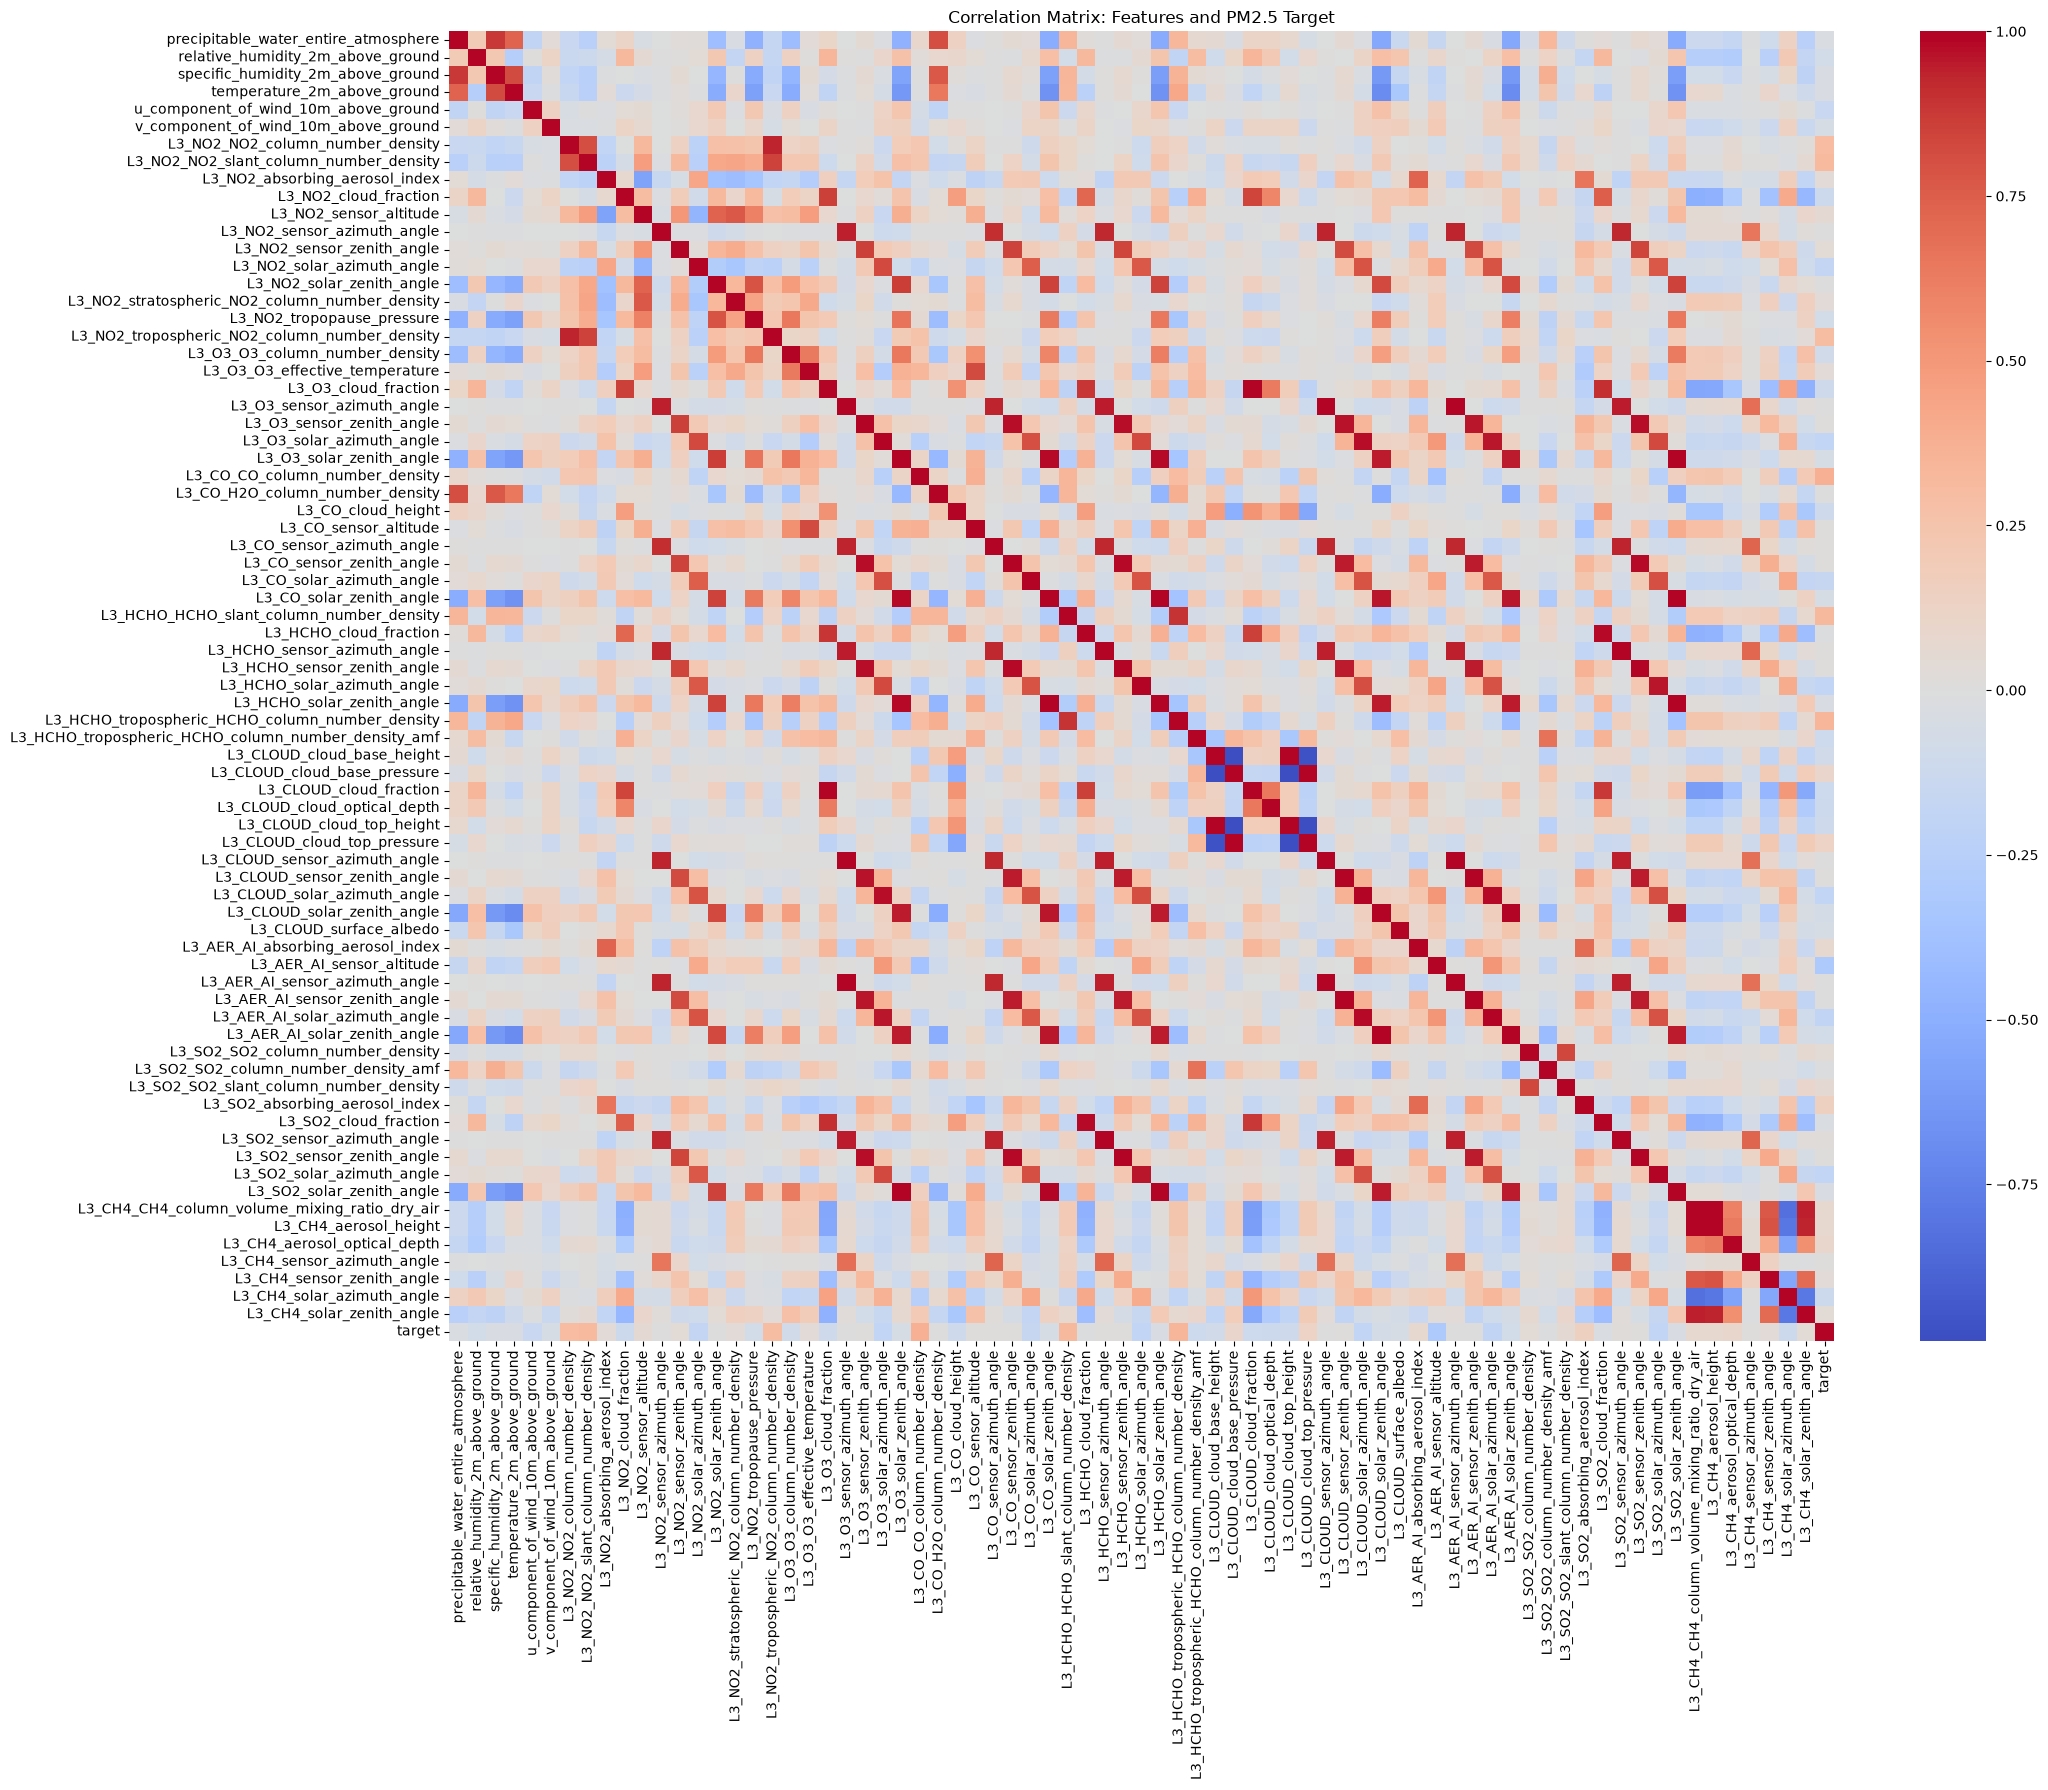

In [14]:
# Explore the Training Data
X_train.info()

# Correlation of each feature with the target
feature_target_correlation = X_train.corrwith(y_train).sort_values(ascending=False)
feature_target_correlation

# Full correlation matrix for all features and the target
correlation_matrix = pd.concat(
    [X_train, y_train.rename("target")],
    axis=1
).corr()
correlation_matrix

# Visualize the full correlation matrix
plt.figure(figsize=(22, 18))
sns.heatmap(correlation_matrix, cmap="coolwarm", center=0)
plt.title("Correlation Matrix: Features and PM2.5 Target")
plt.tight_layout()
plt.show()

In [15]:
# Feature Engineering

{ "workspaceRoot": "c:\\Users\\dahan\\Desktop\\DataScience_neuefische_bootcamp_Berlin\\Machine-Learning-Project-Dahan", "workingDirectory": "c:\\Users\\dahan\\Desktop\\DataScience_neuefische_bootcamp_Berlin\\Machine-Learning-Project-Dahan", "codeSnippet": "import pandas as pd\nfrom pathlib import Path\ntrain = pd.read_csv(Path('data/Train.csv'))\nprint('shape', train.shape)\nprint('missing_total', int(train.isna().sum().sum()))\nprint('dtypes', train.dtypes.value_counts().to_dict())\nprint('date_min_max', train['Date'].min(), train['Date'].max())\nprint('unique_places', train['Place_ID'].nunique())\nprint('target_unique', train['target'].nunique())\nprint('numeric_features', train.select_dtypes(include='number').drop(columns=['target','target_min','target_max','target_variance','target_count'], errors='ignore').shape[1])\nprint('constant_columns', train.columns[train.nunique(dropna=False).eq(1)].tolist())\nprint('id_rows_unique', train['Place_ID X Date'].nunique(), len(train))", "timeout": 30000 }

{'workspaceRoot': 'c:\\Users\\dahan\\Desktop\\DataScience_neuefische_bootcamp_Berlin\\Machine-Learning-Project-Dahan',
 'workingDirectory': 'c:\\Users\\dahan\\Desktop\\DataScience_neuefische_bootcamp_Berlin\\Machine-Learning-Project-Dahan',
 'codeSnippet': "import pandas as pd\nfrom pathlib import Path\ntrain = pd.read_csv(Path('data/Train.csv'))\nprint('shape', train.shape)\nprint('missing_total', int(train.isna().sum().sum()))\nprint('dtypes', train.dtypes.value_counts().to_dict())\nprint('date_min_max', train['Date'].min(), train['Date'].max())\nprint('unique_places', train['Place_ID'].nunique())\nprint('target_unique', train['target'].nunique())\nprint('numeric_features', train.select_dtypes(include='number').drop(columns=['target','target_min','target_max','target_variance','target_count'], errors='ignore').shape[1])\nprint('constant_columns', train.columns[train.nunique(dropna=False).eq(1)].tolist())\nprint('id_rows_unique', train['Place_ID X Date'].nunique(), len(train))",
 'tim

In [39]:
# Learn the fill values on the training set only
train_means = X_train.mean()
X_train = X_train.fillna(train_means)
train_means

precipitable_water_entire_atmosphere    15.302326
relative_humidity_2m_above_ground       70.552747
specific_humidity_2m_above_ground        0.006004
temperature_2m_above_ground              9.321342
u_component_of_wind_10m_above_ground     0.416886
                                          ...    
L3_CH4_aerosol_optical_depth             0.016227
L3_CH4_sensor_azimuth_angle              1.254703
L3_CH4_sensor_zenith_angle              13.849040
L3_CH4_solar_azimuth_angle             -69.098594
L3_CH4_solar_zenith_angle               23.100630
Length: 74, dtype: float64

In [18]:
# Copy the original training data
features = train.drop(
    columns=[
        "target",
        "target_min",
        "target_max",
        "target_variance",
        "target_count",
        "Place_ID X Date",
    ]
).copy()

# Date features
features["Date"] = pd.to_datetime(features["Date"])
features["year"] = features["Date"].dt.year
features["month"] = features["Date"].dt.month
features["day_of_year"] = features["Date"].dt.dayofyear
features["day_of_week"] = features["Date"].dt.dayofweek

# Cyclical seasonal encoding
features["month_sin"] = np.sin(2 * np.pi * features["month"] / 12)
features["month_cos"] = np.cos(2 * np.pi * features["month"] / 12)

# Wind features
features["wind_speed"] = np.sqrt(
    features["u_component_of_wind_10m_above_ground"] ** 2
    + features["v_component_of_wind_10m_above_ground"] ** 2
)

features["wind_direction"] = np.arctan2(
    features["v_component_of_wind_10m_above_ground"],
    features["u_component_of_wind_10m_above_ground"]
)

# Interaction features
features["temperature_humidity"] = (
    features["temperature_2m_above_ground"]
    * features["relative_humidity_2m_above_ground"]
)

features["cloud_aerosol_interaction"] = (
    features["L3_CLOUD_cloud_fraction"]
    * features["L3_AER_AI_absorbing_aerosol_index"]
)

# Remove columns that should not be direct model features
X_train = features.drop(columns=["Date", "Place_ID"])
y_train = train["target"]

In [20]:
X_train.head()


,precipitable_water_entire_atmosphere,relative_humidity_2m_above_ground,specific_humidity_2m_above_ground,temperature_2m_above_ground,u_component_of_wind_10m_above_ground,v_component_of_wind_10m_above_ground,L3_NO2_NO2_column_number_density,L3_NO2_NO2_slant_column_number_density,L3_NO2_absorbing_aerosol_index,L3_NO2_cloud_fraction,...,year,month,day_of_year,day_of_week,month_sin,month_cos,wind_speed,wind_direction,temperature_humidity,cloud_aerosol_interaction
0,11.000000,60.200001,0.00804,18.516840,1.996377,-1.227395,0.000074,0.000156,-1.231330,0.006507,...,2020,1,2,3,0.5,0.866025,2.343506,-0.551239,1114.713758,-0.000000
1,14.600000,48.799999,0.00839,22.546533,3.330430,-1.188108,0.000076,0.000197,-1.082553,0.018360,...,2020,1,3,4,0.5,0.866025,3.536009,-0.342669,1100.270803,-0.064258
2,16.400000,33.400002,0.00750,27.031030,5.065727,3.500559,0.000067,0.000170,-1.001242,0.015904,...,2020,1,4,5,0.5,0.866025,6.157557,0.604679,902.836452,-0.082349
3,6.911948,21.300001,0.00391,23.971857,3.004001,1.099468,0.000083,0.000175,-0.777019,0.055765,...,2020,1,5,6,0.5,0.866025,3.198883,0.350858,510.600575,-0.094451
4,13.900001,44.700001,0.00535,16.816309,2.621787,2.670559,0.000070,0.000142,0.366323,0.028530,...,2020,1,6,0,0.5,0.866025,3.742413,0.794613,751.689007,0.013557


In [24]:
# Train-Test Split
# target is continuous (regression), so stratify=y is not valid here
RANDOM_STATE = 42

X = X_train.copy()
y = y_train.copy()

X_train, X_test, y_train, y_test = train_test_split(
    X,
    y,
    test_size=0.2,
    random_state=RANDOM_STATE
)

# Keep both naming conventions used elsewhere in the notebook
x_train = X_train
x_test = X_test

print(f'X training : {X_train.shape}')
print(f'X test : {X_test.shape}')
print(f'y training : {y_train.shape}')
print(f'y test : {y_test.shape}')


X training : (15644, 84)
X test : (3912, 84)
y training : (15644,)
y test : (3912,)


In [ ]:
def make_pipeline(estimator):
    return Pipeline([('preprocess', preprocessor), ('model', estimator)])

tree_models = {
    'Decision tree (depth)': make_pipeline(DecisionTreeClassifier(random_state=RANDOM_STATE)),
    'Decision tree (depth=3 and min_samples_leaf=5)': make_pipeline(DecisionTreeClassifier(random_state=RANDOM_STATE, max_depth=3, min_samples_leaf=5))
}

tree_rows=[]
for name, model in tree_models.items():
    model.fit(x_train, y_train)
    tree_rows.append({
        'model': name,
        'train_accuracy': accuracy_score(y_train, model.predict(x_train)),
        'test_accuracy': accuracy_score(y_test, model.predict(x_test)),
        'train_auc': roc_auc_score(y_train, model.predict_proba(x_train)[:, 1]),
        'test_auc': roc_auc_score(y_test, model.predict_proba(x_test)[:, 1]),

    })

display(pd.DataFrame(tree_rows))

In [ ]:
# Baseline Model
models = {
    'Random forest': RandomForestClassifier(n_estimators=400, max_features='sqrt', min_samples_leaf=2, oob_score=True, n_jobs=-1, random_state=RANDOM_STATE),
    'Bagging': BaggingClassifier(estimator=DecisionTreeClassifier(max_features=None, random_state=RANDOM_STATE), n_estimators=300, max_samples=0.8, n_jobs=-1, random_state=RANDOM_STATE),
    'AdaBoost': AdaBoostClassifier(n_estimators=250, learning_rate=0.03, random_state=RANDOM_STATE),
    'Gradient boosting': GradientBoostingClassifier(n_estimators=150, learning_rate=0.03, max_depth=2, random_state=RANDOM_STATE),
    'LogitBoost-style (log loss)': GradientBoostingClassifier(loss='log_loss', n_estimators=150, learning_rate=0.03, max_depth=2, random_state=RANDOM_STATE),
    'Stochastic gradient boosting': GradientBoostingClassifier(n_estimators=150, learning_rate=0.03, max_depth=2, subsample=0.75, random_state=RANDOM_STATE),
    'XGBoost': XGBClassifier(n_estimators=200, max_depth=2, learning_rate=0.03, subsample=0.8, colsample_bytree=0.8, eval_metric='logloss', n_jobs=2, random_state=RANDOM_STATE),
}



cv_rows = []
for name, pipeline in fitted_models.items():
    scores = cross_validate(pipeline, X_train, y_train, cv=cv, scoring=scoring, n_jobs=-1)
    cv_rows.append({
        'model': name,
        'cv_auc_mean': scores['test_roc_auc'].mean(),
        'cv_auc_sd': scores['test_roc_auc'].std(),
        'cv_ap_mean': scores['test_average_precision'].mean(),
        'cv_balanced_accuracy': scores['test_balanced_accuracy'].mean(),
    })


In [ ]:
fitted_models = {}
model_rows = []
scoring = {'roc_auc': 'roc_auc', 'average_precision': 'average_precision', 'balanced_accuracy': 'balanced_accuracy', 'neg_log_loss': 'neg_log_loss'}
for name, estimator in models.items():
    pipeline = make_pipeline(estimator)
    pipeline.fit(X_train, y_train)
    fitted_models[name] = pipeline
    probabilities = pipeline.predict_proba(X_test)[:, 1]
    model_rows.append({
        'model': name,
        'test_auc': roc_auc_score(y_test, probabilities),
        'average_precision': average_precision_score(y_test, probabilities),
        'balanced_accuracy': balanced_accuracy_score(y_test, pipeline.predict(X_test)),
        'brier': brier_score_loss(y_test, probabilities),
        'log_loss': log_loss(y_test, probabilities),
        'oob_score': getattr(estimator, 'oob_score_', np.nan) if name == 'Random forest' else np.nan,
        'oob_error': 1 - estimator.oob_score_ if name == 'Random forest' else np.nan,
    })

results = pd.DataFrame(model_rows).sort_values('test_auc', ascending=False)
display(results.round(3))

In [41]:
# Heuristic baseline: ignore the features, always predict the mean training score
from sklearn.metrics import root_mean_squared_error

baseline_prediction = y_train.mean()
baseline_rmse = root_mean_squared_error(y_test, [baseline_prediction] * len(y_test))

print(f"Baseline always predicts: {baseline_prediction:.2f}")
print(f"Baseline test RMSE: {baseline_rmse:.2f}")

NameError: name 'y_test' is not defined

In [38]:
# Train the Model
# X_test and y_test were created in the train-test split cell.


In [ ]:
reg = LinearRegression().fit(X_train, y_train)

In [ ]:
#Evaluate the Model

In [ ]:
# Apply the fitted step (imputation) to the test set, using the training means
X_test = X_test.fillna(train_means)
y_test_pred = reg.predict(X_test)
rmse = root_mean_squared_error(y_test, y_test_pred)
print(rmse)


In [ ]:
# save the best model to a file for later use
import joblib
joblib.dump(reg, "models/linear_regression_model.joblib")

In [ ]:
# use the model to predict the score of a new coffee with these attributes:
 
new_coffee = pd.DataFrame({
    
    "number_of_bags" :[1] ,
    "moisture": [10.5] , 
    "category_one_defects": [0],
    "quakers": [0],
    "category_two_defects": [1], 
    "altitude_low_meters": [1200], 
    "altitude_high_meters": [1500],
    "altitude_mean_meters": [1350]
})
new_coffee = new_coffee.fillna(train_means)  # apply the same imputation as training data

In [ ]:
X_train.columns

In [ ]:
# load the model from the file and use it to predict the score of the new coffee
loaded_model = joblib.load("models/linear_regression_model.joblib")
predicted_score = loaded_model.predict(new_coffee)[0]
print(f"Predicted cupping score for the new coffee: {predicted_score:.2f}")